In [1]:
def function1(input1):
    return input1 + " from first function"

In [2]:
def function2(input2):
    return input2 + " from second function"

In [3]:
def function3(input3):
    return input3 + " from third function"

In [4]:
function1("Swastika")

'Swastika from first function'

In [5]:
from langgraph.graph import StateGraph, END


In [6]:
workflow1=StateGraph(dict)
workflow1.add_node("funct1", function1)

In [7]:
workflow1.add_node("func2", function2)

In [8]:
workflow1.add_edge("funct1", "func2")

In [9]:
workflow1.set_entry_point("funct1")
workflow1.set_finish_point("func2")


In [10]:
app=workflow1.compile()

In [14]:
from IPython.display import Image, display

app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'funct1': Node(id='funct1', name='funct1', data=funct1(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'func2': Node(id='func2', name='func2', data=func2(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='funct1', data=None, conditional=False), Edge(source='funct1', target='func2', data=None, conditional=False), Edge(source='func2', target='__end__', data=None, conditional=False)])

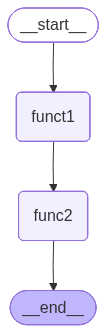

In [15]:
display(Image(app.get_graph().draw_mermaid_png()))

In [16]:
app.invoke("Hi this is Swastika")

'Hi this is Swastika from first function from second function'

In [19]:
for output in app.stream("Hi this is Swastika"):
    for key, value in output.items():
        print(f'here is the output from {key}')
        print('_________________')
        print(value)
        print('\n')

## Visualizing the workflow

here is the output from funct1
_________________
Hi this is Swastika from first function


here is the output from func2
_________________
Hi this is Swastika from first function from second function




In [73]:
from langchain_google_genai import ChatGoogleGenerativeAI

model=ChatGoogleGenerativeAI(model="gemini-flash-latest")


In [90]:
output=model.invoke("iNDIA'S cAPITAL")

output.content

[{'type': 'text',
  'text': 'The capital of India is **New Delhi**.',
  'extras': {'signature': 'Et0CCtoCAb4+9vu8LKkd7xVJYUuUMpR0xjdi8qDQglvEK8fUCVeHTq8ZQ/kVfxNEHmF609HdeKisV/fDmntT2DjA2S807A4WJU0qAxYcDo2tpVatwYCRqCHVvwEOzACQo0cZYVAybmU/APQeFtE2fPuGaCW7gRnyeTYUeb6qb2SPLqy4wcrvZtG6aILgKzRLbKJ0M9X446+QKq+UNhaCEjqh3SVdSZnl01txwxwlr2A7vdJaHmXZhNOZvtrhfLdLPkQZj6wUSsQVNRVYgjyAHmfUkbjgdmoupS3cFWsFprx6uWPUvVOwSaOyIUCe+dfON/jv/B+XW1KskQZhNVns1aKiXzrUNYPAXidpERDnObsZDEwDuZ6wOt2XCt8QAZEE0/GvO/eEvY8Tzbcjga3nn7HljAAcrczMYifSWNPW+gc8mLD5I6uKbpl+CXL7RjCepT4R0MlfBFFYNNqbxXuVSQ=='}}]

In [91]:

def llm(input):
    from langchain_google_genai import ChatGoogleGenerativeAI
    model=ChatGoogleGenerativeAI(model="gemini-flash-latest")
    output=model.invoke(input)
    # return output.content
    return output.content[0]["text"]

In [ ]:
def token_counter(input):
    token=input.split()
    num_tokens=len(token)
    return (f'Number of tokens in the answer: {num_tokens}')

In [93]:
workflow2=StateGraph(dict)

In [94]:
workflow2.add_node("My_LLM", llm)

In [95]:
workflow2.add_node("LLM_Output_Token_Counter", token_counter)

In [96]:
workflow2.add_edge("My_LLM", "LLM_Output_Token_Counter")

In [97]:
workflow2.set_entry_point("My_LLM")
workflow2.set_finish_point("LLM_Output_Token_Counter")

In [98]:
app2=workflow2.compile()

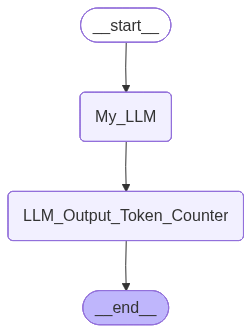

In [99]:
display(Image(app2.get_graph().draw_mermaid_png()))

In [101]:
app2.invoke("Can you please tell me about capital of India?")

iNPUT The capital of India is **New Delhi**.

It is a city that blends rich history with modern political significance. Here are the key things to know about it:

### 1. History and Origin
*   **The Shift:** Before New Delhi, the capital of British India was **Calcutta** (now Kolkata). In **1911**, during the Delhi Durbar, King George V announced that the capital would be shifted to Delhi.
*   **Design:** The city was planned and designed by British architects **Edwin Lutyens** and **Herbert Baker**. Because of this, the central administrative area is often referred to as "Lutyens' Delhi."
*   **Inauguration:** While the foundation was laid in 1911, the city was officially inaugurated as the capital on February 13, 1931.

### 2. Political Significance
New Delhi is the seat of all three branches of the Government of India:
*   **Executive:** It houses the **Rashtrapati Bhavan** (the President's official residence) and the Prime Minister’s Office.
*   **Legislative:** It is home to the *

'Number of tokens in the answer: 495'

In [102]:
app2.invoke("Tell me about Hidden Brains Infotech pvt. ltd in very detail?")

iNPUT **Hidden Brains Infotech Pvt. Ltd.** is a prominent global technology solution and IT consulting company based in India. Since its inception, it has grown into one of the leading names in the offshore software development industry, catering to startups, SMEs, and Fortune 500 companies.

Here is a detailed breakdown of the company across various dimensions:

---

### 1. Company Overview
*   **Founded:** 2003
*   **Headquarters:** Ahmedabad, Gujarat, India.
*   **Founder/CEO:** Vishal Chhawchharia (Co-founder & CEO).
*   **Certifications:** CMMI Level 3, ISO 9001:2015, and ISO 27001:2013 certified.
*   **Global Presence:** Beyond its massive delivery center in India, it has a physical presence or regional offices in the **USA, UK, Norway, and UAE.**

### 2. Core Services and Expertise
Hidden Brains offers a wide spectrum of IT services, categorized into several key pillars:

#### A. Web Development
*   **Custom Web Development:** Using frameworks like Laravel, Node.js, and Python.


'Number of tokens in the answer: 775'